# 量子密钥分发

## 引言

当Alice和Bob想要通过不安全的信道（如互联网）传递一个秘密消息（如Bob的网上银行信息）时，对消息进行加密是至关重要的。密码学要求Alice和Bob拥有一个只有他们知道的秘密密钥，这个密钥允许他们使用对称密钥加密进行通信。

如果Alice和Bob想使用Eve的经典通信信道来共享他们的密钥，就无法判断Eve是否为自己制作了这个密钥的副本——他们必须完全信任Eve没有窃听。然而，如果Eve提供了一个量子通信信道，Alice和Bob就不再需要信任Eve了——如果Eve试图在Bob的消息到达Alice之前读取它，他们就会知道。

对于一些读者而言，了解如何在物理层面上构建量子信道可能颇具帮助。举一个经典信道的例子，比如电话线；我们通过电话线传送代表信息（或比特）的电信号。而一个典型的量子通信信道的例子是光纤，通过该光纤我们可以发送单个光子。光子具有一种称为偏振的属性，该偏振能呈现出两种不同的状态。我们可以利用这一特性来表达一个量子比特。

## 协议概述

该协议利用了测量量子比特可以改变其状态这一事实。如果Alice向Bob发送一个量子比特，而窃听者（Eve）试图在Bob之前测量它，那么Eve的测量有可能改变量子比特的状态，Bob就不会接收到Alice发送的量子比特状态。

如果Alice将一个量子比特制备成 $|+\rangle$ 态(`0`在 $X$ 基向量中)，而Bob在 $X$ 基向量中测量它，那么Bob一定会测量到`0`：

但是，如果Eve试图在量子比特到达Bob之前在 $Z$ 基向量中测量它，她将把量子比特的状态从 $|+\rangle$ 改变为 $|0\rangle$ 或 $|1\rangle$，Bob就不再一定测量到`0`，而是有50%的几率测量到`1`，如果他真的测量到了`1`，他和Alice就会知道他们的信道出了问题。

量子密钥分发协议需要重复这个过程足够多次，使窃听者几乎没有机会逃脱拦截的可能。大致过程如下:

**- 第1步**

Alice选择一串随机比特，例如：

`1000101011010100`

以及每个比特随机选择的基向量：

`ZZXZXXXZXZXXXXXX`

Alice将这两条信息保密。

**- 第2步**

然后Alice使用她选择的基向量将每个比特编码到一串量子比特上；这意味着每个量子比特都处于随机选择的状态 $|0\rangle$、$|1\rangle$、$|+\rangle$ 或 $|-\rangle$ 之一。在本例中，量子比特串如下所示:

$$
|1\rangle|0\rangle|+\rangle|0\rangle|-\rangle|+\rangle|-\rangle|0\rangle|-\rangle|1\rangle|+\rangle|-\rangle|+\rangle|-\rangle|+\rangle|+\rangle
$$

这就是她发送给Bob的消息。

**- 第3步**

然后Bob随机测量每个量子比特，例如，他可能使用以下基向量：

`XZZZXZXZXZXZZZXZ`

Bob将测量结果保密。

**- 第4步**

然后Bob和Alice公开分享他们对每个量子比特使用的基向量。如果Bob用与Alice制备量子比特时相同的基向量测量了一个量子比特，他们就用这个结果来形成部分共享的秘密密钥，否则就丢弃该比特的信息。

**- 第5步**

最后，Bob和Alice共享他们密钥的随机样本，如果样本匹配，他们就可以确定（在一个小的误差范围内）他们的传输是成功的。

## DeepQuantum示例：无拦截情况

让我们首先看看在没有人窃听的情况下协议是如何工作的，然后我们可以看到Alice和Bob如何能够检测到窃听者。

### 第1步：

为了生成伪随机密钥，我们将使用numpy的 `randint` 函数。为了确保你能重现本页面上的结果，我们将种子设置为0。

我们将Alice初始消息的长度称为 `n`。在这个例子中，Alice将发送一个100个量子比特长的消息。

Alice生成她的随机比特集：

In [5]:
import deepquantum as dq
import numpy as np
from numpy.random import randint

np.random.seed(seed=0)
n = 100
## Step 1
# Alice generates bits
alice_bits = randint(2, size=n)
print(alice_bits)

[0 1 1 0 1 1 1 1 1 1 1 0 0 1 0 0 0 0 0 1 0 1 1 0 0 1 1 1 1 0 1 0 1 0 1 1 0
 1 1 0 0 1 0 1 1 1 1 1 0 1 0 1 1 1 1 0 1 0 0 1 1 0 1 0 1 0 0 0 0 0 1 1 0 0
 0 1 1 0 1 0 0 1 0 1 1 1 1 1 1 0 1 1 0 0 1 0 0 1 1 0]


此时，比特集 `alice_bits` 只有Alice知道。我们将跟踪只有Alice知道的信息、只有Bob知道的信息以及通过Eve的信道发送的信息，如下表所示：

| Alice知道的信息 | 通过Eve的信道 | Bob知道的信息 |
| :--- | :--- | :--- |
| alice_bits | | |

### 第2步：

Alice随机选择在 $X$ 或 $Z$ 基向量中对每个比特进行编码，并将每个量子比特的选择存储在 `alice_bases` 中。在本例中，`0` 表示"在 $Z$ 基向量中制备"，`1` 表示"在 $X$ 基向量中制备"：

In [6]:
np.random.seed(seed=0)
n = 100
## Step 1
# Alice generates bits
alice_bits = randint(2, size=n)

## Step 2
# Create an array to tell us which qubits
# are encoded in which bases
alice_bases = randint(2, size=n)
print(alice_bases)

[1 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0 1 0 1 0 1 1 1 1 1 0 1 1 1 1 0 1 1 0 0 1 0
 0 0 0 1 1 0 0 1 0 1 1 1 1 0 0 0 1 0 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 1 0
 1 0 1 0 0 0 1 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0]


Alice也对这一知识保密：

| Alice 知道的信息 | 通过 Eve 的信道 | Bob 知道的信息 |
| :---: | :---: | :---: |
| alice_bits | | |
| alice_bases | | |

下面的 `encode_message` 函数创建了一个 `QuantumCircuit` 的列表，每个线路代表Alice消息中的一个量子比特：

In [7]:
def encode_message(bits, bases):
    message = []
    for i in range(n):
        cir = dq.QubitCircuit(1)
        if bases[i] == 0:  # Prepare qubit in Z-basis
            if bits[i] == 0:
                pass
            else:
                cir.x(0)
        else:  # Prepare qubit in X-basis
            if bits[i] == 0:
                cir.h(0)
            else:
                cir.x(0)
                cir.h(0)
        cir.barrier()
        message.append(cir)
    return message


np.random.seed(seed=0)
n = 100

## Step 1
# Alice generates bits
alice_bits = randint(2, size=n)

## Step 2
# Create an array to tell us which qubits
# are encoded in which bases
alice_bases = randint(2, size=n)
message = encode_message(alice_bits, alice_bases)

我们可以看到 `alices_bits` 中的第一个比特是 `0`，她对它进行编码的基向量是 $X$ 基向量(用 `1` 表示)：

In [11]:
print(f'bit = {alice_bits[0]}')
print(f'basis = {alice_bases[0]}')

bit = 0
basis = 1


如果我们查看 `message` 中的第一个线路(代表Alice消息中的第一个量子比特)，我们可以验证Alice已经制备了一个状态为 $|+\rangle$ 的量子比特:

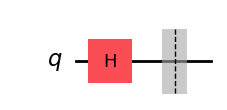

In [12]:
message[0].draw()

另一个例子是，我们可以看到 `alice_bits` 中的第五个比特是 `1`，它在 $Z$ 基向量中编码，Alice将相应的量子比特制备成 $|1\rangle$ 态：

bit = 1
basis = 0


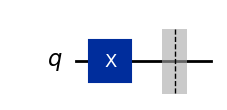

In [17]:
print(f'bit = {alice_bits[4]}')
print(f'basis = {alice_bases[4]}')
message[4].draw()

然后这个量子比特消息通过Eve的量子信道发送给Bob：

| Alice 知道的信息 | 通过 Eve 的信道 | Bob 知道的信息 |
| :---: | :---: | :---: |
| alice_bits | | |
| alice_bases | | |
| message | message | message |

### 第3步：

Bob随机选择X基或Z基测量每个量子比特，并存储这些信息：

In [18]:
np.random.seed(seed=0)
n = 100

## Step 1
# Alice generates bits
alice_bits = randint(2, size=n)

## Step 2
# Create an array to tell us which qubits
# are encoded in which bases
alice_bases = randint(2, size=n)
message = encode_message(alice_bits, alice_bases)

## Step 3
# Decide which basis to measure in:
bob_bases = randint(2, size=n)
print(bob_bases)

[1 0 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 1 0 1 0 0 0 1 1 1 0 0 1 1 1 1 0 0 0 1 1
 0 1 0 0 1 0 1 1 1 1 0 0 0 1 1 1 0 1 1 1 1 0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 0
 0 0 1 0 1 0 1 1 0 0 0 1 0 0 1 1 1 1 0 1 0 0 0 0 1 1]


下面，`measure_message`函数对每个量子比特应用相应的测量，并模拟测量结果。我们将测量结果存储在`bob_results`中。

In [19]:
def measure_message(message, bases):

    measurements = []
    for q in range(n):
        if bases[q] == 1:  # measuring in X-basis
            message[q].h(0)

        message[q]()
        qobj = message[q].measure(shots=1)
        measured_bit = int(list(qobj.keys())[0])
        measurements.append(measured_bit)
    return measurements


np.random.seed(seed=0)
n = 100

## Step 1
# Alice generates bits
alice_bits = randint(2, size=n)

## Step 2
# Create an array to tell us which qubits
# are encoded in which bases
alice_bases = randint(2, size=n)
message = encode_message(alice_bits, alice_bases)

## Step 3
# Decide which basis to measure in:
bob_bases = randint(2, size=n)
bob_results = measure_message(message, bob_bases)

我们可以看到，代表第0个量子比特的线路`message[0]`被Bob添加了X测量：

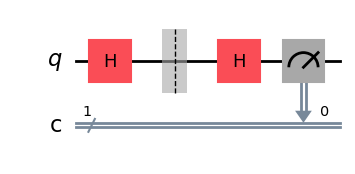

In [20]:
message[0].draw()

由于Bob恰好选择了与Alice编码该量子比特相同的基，Bob必然会得到结果`0`。对于第7个量子比特（如下所示），Bob随机选择的测量与Alice的不同，Bob的结果只有50%的概率与Alice的匹配。

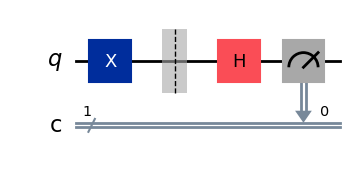

In [21]:
message[6].draw()

In [22]:
print(bob_results)

[0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0]


Bob对他的测量结果保密。

| Alice 知道的信息 | 经过 Eve 的信道 | Bob 知道的信息 |
| :---: | :---: | :---: |
| alice_bits | | |
| alice_bases | | |
| message | message | message |
| | | bob_bases |
| | | bob_results |

### 第4步：

此后，Alice 通过 Eve 的频道公开了每个量子比特是用哪种基态编码的：

| Alice 知道的信息 | 经过 Eve 的信道 | Bob 知道的信息 |
| :---: | :---: | :---: |
| alice_bits | | |
| alice_bases | | |
| message | message | message |
| | | bob_bases |
| | | bob_results |
| | alice_bases | alice_bases |

然后 Bob 公开他测量每个量子比特所用的基态：

| Alice 知道的信息 | 经过 Eve 的信道 | Bob 知道的信息 |
| :---: | :---: | :---: |
| alice_bits | | |
| alice_bases | | |
| message | message | message |
| | | bob_bases |
| | | bob_results |
| | alice_bases | alice_bases |
| bob_bases | bob_bases | |

如果 Bob 恰好使用 Alice 准备的相同基态测量了某个比特，这意味着 `bob_results` 中的相应条目将与 `alice_bits` 中的相应条目匹配，他们可以将该比特作为他们密钥的一部分。如果他们使用不同的基态进行测量，Bob 的结果就是随机的，他们都需要丢弃该条目。以下是一个名为 `remove_garbage` 的函数，它为我们完成了这项工作：

In [23]:
def remove_garbage(a_bases, b_bases, bits):
    good_bits = []
    for q in range(n):
        if a_bases[q] == b_bases[q]:
            # 如果双方使用了相同的基态，将其添加到“好”比特的列表中
            good_bits.append(bits[q])
    return good_bits

Alice和Bob都丢弃无用的比特，使用剩下的比特形成他们的秘钥：

In [24]:
np.random.seed(seed=0)
n = 100

## Step 1
# Alice generates bits
alice_bits = randint(2, size=n)

## Step 2
# Create an array to tell us which qubits
# are encoded in which bases
alice_bases = randint(2, size=n)
message = encode_message(alice_bits, alice_bases)

## Step 3
# Decide which basis to measure in:
bob_bases = randint(2, size=n)
bob_results = measure_message(message, bob_bases)

## Step 4
alice_key = remove_garbage(alice_bases, bob_bases, alice_bits)
print(alice_key)

[np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(0), np.int32(1), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(0), np.int32(1), np.int32(0), np.int32(1), np.int32(1), np.int32(0), np.int32(1), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(0), np.int32(0), np.int32(1), np.int32(1), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(0), np.int32(0), np.int32(1), np.int32(0), np.int32(0)]


Alice和Bob都丢弃无用的比特，使用剩下的比特形成他们的秘密密钥：

In [25]:
np.random.seed(seed=0)
n = 100

## Step 1
# Alice generates bits
alice_bits = randint(2, size=n)

## Step 2
# Create an array to tell us which qubits
# are encoded in which bases
alice_bases = randint(2, size=n)
message = encode_message(alice_bits, alice_bases)

## Step 3
# Decide which basis to measure in:
bob_bases = randint(2, size=n)
bob_results = measure_message(message, bob_bases)

## Step 4
alice_key = remove_garbage(alice_bases, bob_bases, alice_bits)
bob_key = remove_garbage(alice_bases, bob_bases, bob_results)
print(bob_key)

[0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0]


| Alice 知道的信息 | 经过 Eve 的信道 | Bob 知道的信息 |
| :---: | :---: | :---: |
| alice_bits | | |
| alice_bases | | |
| message | message | message |
| | | bob_bases |
| | | bob_results |
| | alice_bases | alice_bases |
| bob_bases | bob_bases | |
| alice_key | | bob_key |

### 第5步：

最后，Bob和Alice比较他们密钥中随机选择的一些比特，以确保协议正确工作：

In [26]:
def sample_bits(bits, selection):
    sample = []
    for i in selection:
        # use np.mod to make sure the
        # bit we sample is always in
        # the list range
        i = np.mod(i, len(bits))
        # pop(i) removes the element of the
        # list at index 'i'
        sample.append(bits.pop(i))
    return sample

Alice和Bob都公开这些比特，并从密钥中删除，因为它们不再是秘密：

In [27]:
np.random.seed(seed=0)
n = 100

## Step 1
# Alice generates bits
alice_bits = randint(2, size=n)

## Step 2
# Create an array to tell us which qubits
# are encoded in which bases
alice_bases = randint(2, size=n)
message = encode_message(alice_bits, alice_bases)

## Step 3
# Decide which basis to measure in:
bob_bases = randint(2, size=n)
bob_results = measure_message(message, bob_bases)

## Step 4
alice_key = remove_garbage(alice_bases, bob_bases, alice_bits)
bob_key = remove_garbage(alice_bases, bob_bases, bob_results)

## Step 5
sample_size = 15
bit_selection = randint(n, size=sample_size)

bob_sample = sample_bits(bob_key, bit_selection)
print('  bob_sample = ' + str(bob_sample))
alice_sample = sample_bits(alice_key, bit_selection)
print('alice_sample = ' + str(alice_sample))

  bob_sample = [0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
alice_sample = [np.int32(0), np.int32(1), np.int32(0), np.int32(1), np.int32(1), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(0), np.int32(0), np.int32(0)]


| Alice 知道的信息 | 经过 Eve 的信道 | Bob 知道的信息 |
| :---: | :---: | :---: |
| alice_bits | | |
| alice_bases | | |
| message | message | message |
| | | bob_bases |
| | | bob_results |
| | alice_bases | alice_bases |
| bob_bases | bob_bases | |
| alice_key | | bob_key |
| bob_sample | bob_sample | bob_sample |
| alice_sample | alice_sample | alice_sample |

如果协议正确工作且没有干扰，他们的样本应该匹配：

In [ ]:
print(bob_sample == alice_sample)

True

如果他们的样本匹配，这意味着（以很高的概率）`alice_key == bob_key`。现在他们共享了一个秘密密钥，可以用来加密他们的消息！

| Alice 知道的信息 | 经过 Eve 的信道 | Bob 知道的信息 |
| :---: | :---: | :---: |
| alice_bits | | |
| alice_bases | | |
| message | message | message |
| | | bob_bases |
| | | bob_results |
| | alice_bases | alice_bases |
| bob_bases | bob_bases | |
| alice_key | | bob_key |
| bob_sample | bob_sample | bob_sample |
| alice_sample | alice_sample | alice_sample |
| shared_key | | shared_key |


## DeepQuantum示例：有窃听

现在让我们看看，如果Eve试图窃听他们的量子消息，Alice和Bob如何发现。我们重复之前没有干扰时的相同步骤，但在Bob收到量子比特之前，Eve会试图从中提取一些信息。让我们设置一个不同的随机种子，以获得一组特定的可重复的随机结果。

### 第1步：

Alice生成一组随机比特：

In [29]:
np.random.seed(seed=3)
## Step 1
alice_bits = randint(2, size=n)
print(alice_bits)

[0 0 1 1 0 0 0 1 1 1 0 1 1 1 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 0 1 1 0 1
 0 0 1 1 0 0 1 0 1 0 1 1 1 1 0 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 1 0 1 0 0 1 1 0 1 0 0 0 0 0 1 1 0 1 1]


### 第2步：

Alice随机地用 $Z$ 基和 $X$ 基对这些比特进行编码，并通过Eve的量子信道将它们发送给Bob：

In [30]:
np.random.seed(seed=3)
## Step 1
alice_bits = randint(2, size=n)
## Step 2
alice_bases = randint(2, size=n)
message = encode_message(alice_bits, alice_bases)
print(alice_bases)

[1 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 0 0 1 1 0 0 1 1 1 1 0 0
 1 1 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 1 1 1 0 0 1 0 1 0 1 1 0 0 1 0 0 1 1 1 1
 1 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 1 1]


在这种情况下，Alice消息中的第一个量子比特处于状态 $|+\rangle$ ：

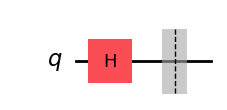

In [31]:
message[0].draw()

Eve在消息通过她的信道时对其进行了拦截。她试图用随机选择的基测量这些量子比特，就像Bob稍后会做的那样。

In [34]:
np.random.seed(seed=3)
## Step 1
alice_bits = randint(2, size=n)
## Step 2
alice_bases = randint(2, size=n)
message = encode_message(alice_bits, alice_bases)
## Interception!!
eve_bases = randint(2, size=n)
intercepted_message = measure_message(message, eve_bases)
print(intercepted_message)

[1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0]


我们可以看到第1个量子比特的情况：Eve随机选择的基与Alice的不同，这将使量子比特状态从 $|+\rangle$ 变为 $Z$ 基上的随机状态，有50%的概率为 $|0\rangle$ 或 $|1\rangle$ ：

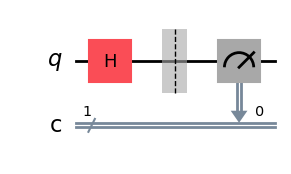

In [35]:
message[0].draw()

### 第3步：

然后Eve将量子比特传递给Bob，Bob随机测量它们。在这种情况下，Bob（碰巧）选择用与Alice准备该量子比特相同的基进行测量。如果没有拦截，Bob必然会测得`0`，但由于Eve试图读取消息，他现在有50%的概率测得`1`。

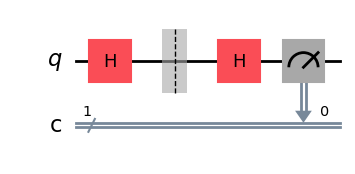

In [36]:
np.random.seed(seed=3)
## Step 1
alice_bits = randint(2, size=n)
## Step 2
alice_bases = randint(2, size=n)
message = encode_message(alice_bits, alice_bases)
## Interception!!
eve_bases = randint(2, size=n)
intercepted_message = measure_message(message, eve_bases)
## Step 3
bob_bases = randint(2, size=n)
bob_results = measure_message(message, bob_bases)
message[0].draw()

### 第4步：

Bob和Alice公开他们的基选择，并丢弃无用的比特：

In [37]:
np.random.seed(seed=3)
## Step 1
alice_bits = randint(2, size=n)
## Step 2
alice_bases = randint(2, size=n)
message = encode_message(alice_bits, alice_bases)
## Interception!!
eve_bases = randint(2, size=n)
intercepted_message = measure_message(message, eve_bases)
## Step 3
bob_bases = randint(2, size=n)
bob_results = measure_message(message, bob_bases)
## Step 4
bob_key = remove_garbage(alice_bases, bob_bases, bob_results)
alice_key = remove_garbage(alice_bases, bob_bases, alice_bits)

### 第5步：

Bob和Alice比较他们密钥中相同的随机选择，看看量子比特是否被拦截：

In [38]:
np.random.seed(seed=3)
## Step 1
alice_bits = randint(2, size=n)
## Step 2
alice_bases = randint(2, size=n)
message = encode_message(alice_bits, alice_bases)
## Interception!!
eve_bases = randint(2, size=n)
intercepted_message = measure_message(message, eve_bases)
## Step 3
bob_bases = randint(2, size=n)
bob_results = measure_message(message, bob_bases)
## Step 4
bob_key = remove_garbage(alice_bases, bob_bases, bob_results)
alice_key = remove_garbage(alice_bases, bob_bases, alice_bits)
## Step 5
sample_size = 15
bit_selection = randint(n, size=sample_size)
bob_sample = sample_bits(bob_key, bit_selection)
print('  bob_sample = ' + str(bob_sample))
alice_sample = sample_bits(alice_key, bit_selection)
print('alice_sample = ' + str(alice_sample))

  bob_sample = [1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1]
alice_sample = [np.int32(1), np.int32(1), np.int32(0), np.int32(0), np.int32(1), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(0), np.int32(0), np.int32(0)]


In [ ]:
print(bob_sample == alice_sample)

False

Bob的密钥和Alice的密钥不匹配。我们知道这是因为Eve在第2步和第3步之间试图读取消息，改变了量子比特的状态。就Alice和Bob而言，这可能是由于信道中的噪声造成的，但无论如何，他们都必须丢弃所有结果并重试——Eve的拦截企图失败了。

## 风险分析

对于这种Eve测量所有量子比特的拦截类型，Bob和Alice的样本有很小的概率匹配，Alice通过Eve的信道发送她的易受攻击的消息。让我们计算这种概率，看看量子密钥分发的风险有多大。

- 要让Alice和Bob使用一个量子比特的结果，他们必须都选择相同的基。如果Eve也选择了这个基，她将成功拦截这个比特而不引入任何错误。这种情况发生的概率为50%。
- 如果Eve选择了错误的基，即与Alice和Bob不同的基，Bob仍有50%的概率测量到Alice试图发送的值。在这种情况下，拦截也不会被发现。
- 但如果Eve选择了错误的基，即与Alice和Bob不同的基，Bob有50%的概率不会测量到Alice试图发送的值，这将在他们的密钥中引入一个错误。

如果Alice和Bob比较他们密钥中的1个比特，比特匹配的概率为0.75，这样他们就不会注意到Eve的拦截。如果他们测量2个比特，拦截不被发现的概率为 $0.75^2 = 0.5625$ 。我们可以看到，根据爱丽丝和鲍勃选择比较的比特数（x），可以计算出Eve不被发现的概率：

$$ P(不被发现) = 0.75^x $$

如果我们决定像上面那样比较15个比特，Eve不被发现的概率为1.3%。如果这对我们来说风险太大，我们可以比较50个比特，有0.00006%的概率在不知情的情况下被监听。